# Chapter 1. 실습 환경 구축 
- 우분투 운영체제 이미지 다운로드, 버추얼 박스 설치 . 네트워크 설정, PuTTY  초기 설치. vim 기본 사용 
## 1.1 우분투 이미지 다운. 
## 1.2 버추얼 박스 설치 
???
## 2.1.1 운영체제 
- 스레드, 메인 스레드, 네임 스페이스 :  프로세스를 실행할 떄 시스템 리소스를 분리해서 실행. 
- namespace : 
    pid : process id, 리눅스 커널의 프로세스 id 분리
    net :  네트워크 인터페이스 관리
    ipc : 프로세스간 ipc 통신 접근 관리 
    mnt : 파일 시스템의 마운트를 관리
    uts : 커널과 버전 식별자 관리 
- docker client ( docker-cli) 우분투에서 실행하는 터미널 과 같음. build, pull, run
- Docker Daemon  과 도커 클라이언트와 통신 
- containerd: 컨테이너 실행과 관리에 필요한 기능을 수행하는 오픈소스 컨테이너 런타임. 컨테이너의 생성 주기 관리. 
    - 도커 이미지 전송, 컨테이너 실행, 스토리지, 네트워킹,  고수준 컨테이너 런타임 .
- containerd-shim :
    - containerd 와 runc 사이에 작동하는 중간 프로세스. 

## 3.1 도커 설치 
- https://docs.docker.com/engine/install/ubuntu


==
> 2024.12.10

## 4.1 도커 기초 
## 4.1.2 도커 이미지 
- 컨테이너 형태로 솦트웨어 배포하기윟 필요한 모든 요소( 코드,라이브러리, 설정 etc) 를 실행할수 있는 포맷. 컴파일,빌드 패키지
- 독립적, 의존성을 고려할 필요 없음. 경량화. 도커컨테이너 상태를 담은 스냅숏 개념. -> 이미지로 컨테이너 많이 생성가능
- 도커 허브 업로드, 다운로드 가능. 
## 4.1.3 도커 컨테이너 
- 도커 이미지 실행 가능 인스턴스 , 실행,중지, 재실행, 삭제 등 명령 가능. 
- 자체 파일 시스템 보유, 각 컨테이너는 독립. 컨테이너는 운영체제를 포함하지 않기 에 매우 가벼움. 도커 운영체제를 사용. 

## 4.2 도커 기초 명령 
- 이미지 :  이미지 인덱스(digest), 이미지 매니페스트, 레이어 세 구조로 이루어져있음
- image manifest : 다양한 운영체제 및 아키텍처에서 해당 이미지 활용 가능하도록 설정값과 레이어 제공
- container 는 내부 프로세스가 모두 종료되면 컨테이너도 역시 종료 됨. 0 은 정상 종료 됨. 

- $ docker image pull ubuntu
- $ docker image pull python:3.11.6
- $ docker image ls # image list 
- $ docker container run ubuntu  # 우분투 이미지를 컨테이너로 실행 
- $ docker container run python:3.11.6
- $ docker container ls  # container 실행 중 컨테이너 리스트
- $ docker container ls -a # 모든 컨테이너 리스트 .

### 4.2.6 컨테이너 내부 접속 
- docker container run -it ubuntu # interactive(STDIN) tty(가상 터미널)
- $ apt update && apt install net-tools ## apt 업데이트 및 네트워크 
- # exit 
- $ docker container stop  [Id]( 10초 후 종료 )
- $ docker container kill [Id]( 바로 종료 )
- $ docker container attach [Id] ( 종료된 컨테이너에 다시 접속)
- $ docker container rm [Id] (컨테이너 삭제 )

### 4.2.8 이미지 삭제 
- docker image rm [id]

### 4.2.9 docker image 변경
- ubuntu 에 net-tool  layer 를 입힌 이미지로 변경 
- $ docker container commit [Id] my-ubuntu:0.1 # layer 추가된 우분투를 이미지로 저장

### 4.2.10 docker image 명령어 모음
- docker image build(이미지 빌드), history (이미지 힘스토리), import (tarball 콘텐츠 임포트 )
- inspect( 이미지 정보 표시 ), load(타볼로 묶인 이미지 로드), ls(목록), prune(미사용 이미지 삭제),
- pull(레지로 부터 이미지 다운), push(이미지 업), rm(하나이상 삭제), save( 타볼로 저장), tag(태그 생성)

### 4.2.11 docker container 명령어 모음 
- (docker container +) create(새 컨테이너 생성), start(정지상태를 실행), run(생성후 실행까지)
- ++ attach(실행중 컨테이너의 표준 입출력 스트림에 붙음)
- ++ exec ( 실행중인 컨테이너에 명령어를 실행)
- // attach vs exac : attach 는 stdin,stdout,sterr 스트림에 연결시 사용. 

- ++ diff(컨테이너 파일 시스템의 변경 내용 검사 )
- ++ commit( 변경된 컨테이너에 대한 새로운 이미지 생성)
- ++ cp (컨테이너 와 로컬 파일 시스템간 파일,폴더를 복사 )
- export, inspect, kill, logs, ls, pause(컨테이너 내부 프로세스 정지), port(매핑된 포트리스트), prune,
rename(이름 변경), restart, rm, run, start, stats(컨테이너 리소스 사용 통계), stop, top(실행중 프로세스),
unpausee(정지를 재실행), update(하나이상의 ct 설정 업데이트), wait( 종료될때 까지 기다린후 exit code 표시 )

-docker container start 27ae3eb4e649 
docker container attach  27ae3eb4e649
== 39



[Docker]1.실습환경구축.ipynb       docker_process.png


In [2]:
# Basic
import sys,os ; sys.path.append("./../")
from DataPreprocessing_ import *
from Modeling import *


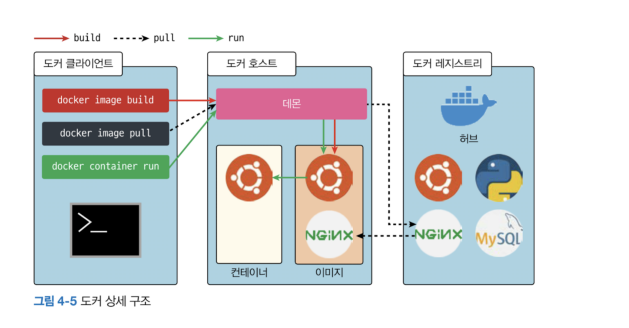

🥇 image structure


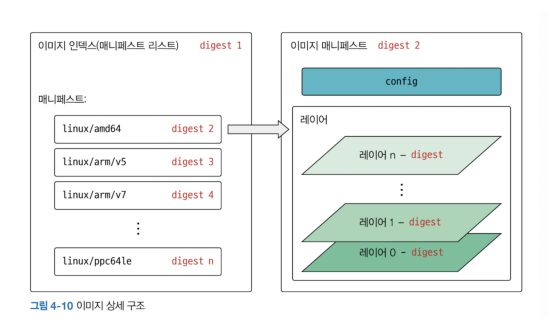

In [9]:
image_show("./docker_process.png")
y(" image structure")
image_show("./docker_image_structure.png")